In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA 1: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

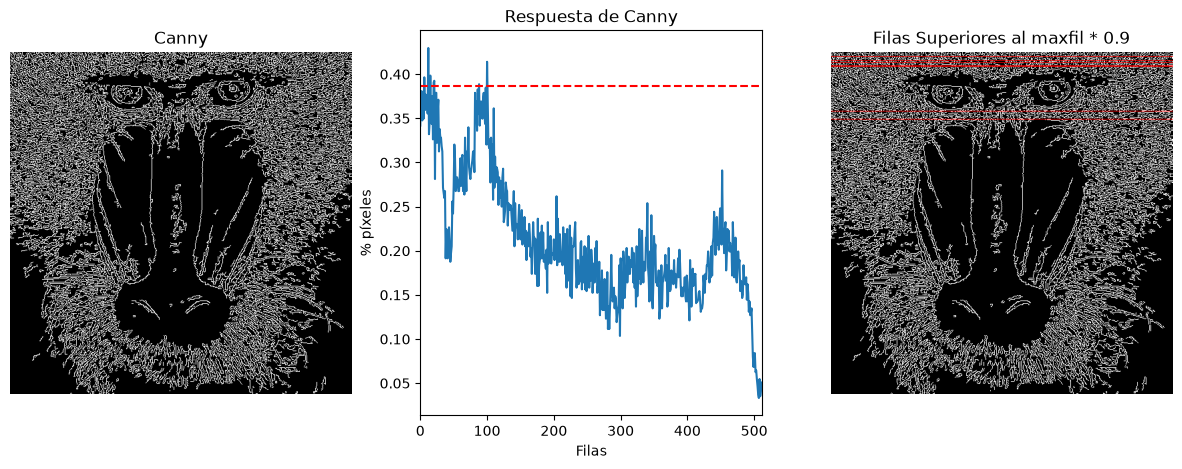

In [3]:
img = cv2.imread('mandril.jpg') 
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

rows = row_counts / (255 * canny.shape[1])
umbral = max(rows) * 0.9
filas_sel = np.where(rows >= umbral)[0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 3, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)

#Linea discontinua que indica donde está el maxfil*0.9
plt.axhline(umbral, color='red', linestyle='--')
plt.xlim([0, canny.shape[1]])

#Imagen de canny a RGB
img_resultado = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
#Dandole color rojo a las filas blancas que superen el maxfil*0.9
img_resultado[filas_sel, :] = [255, 0, 0]

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title("Filas Superiores al maxfil * 0.9")
plt.imshow(img_resultado)


TAREA 2: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

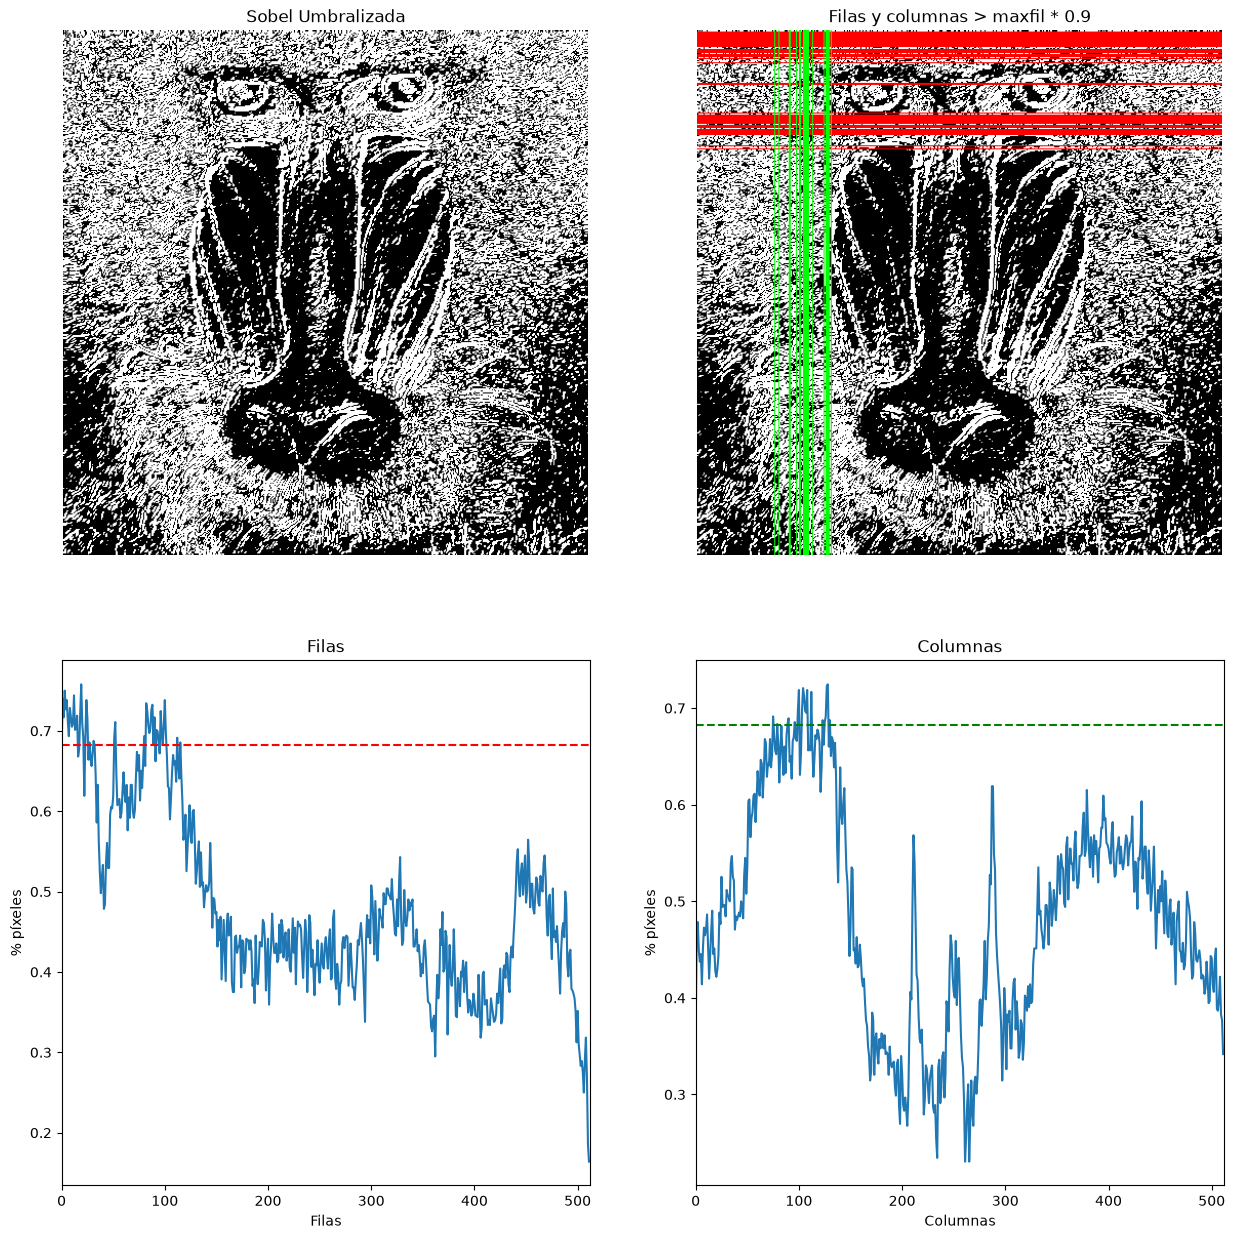

In [4]:

ggris = cv2.GaussianBlur(gris, (3, 3), 0)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y

#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

#Conversión 8 bits
sobel_8u = cv2.convertScaleAbs(sobel)

#Imagen umbralizada
valorUmbral = 40
_, imagenUmbralizada = cv2.threshold(sobel_8u, valorUmbral, 255, cv2.THRESH_BINARY)

#Muestra la imagen
plt.figure(figsize=(15, 15))
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title('Sobel Umbralizada')

#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(imagenUmbralizada), cmap='gray') 

#Filas y columnas
row_counts = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#cálculo del umbral máximo para las filas y columnas
rows = row_counts / (255 * sobel.shape[1])
cols = col_counts[0] / (255 * sobel.shape[0])

max_row = max(rows) * 0.9
max_cols = max(cols) *0.9

if max_row > max_cols:
    umbral = max_row
else:
    umbral = max_cols
filas_sel = np.where(rows >= umbral)[0]

plt.subplot(2, 2, 3)
plt.title("Filas")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)

#Linea discontinua que indica donde está el maxfil*0.9
plt.axhline(umbral, color='red', linestyle='--')
plt.xlim([0, canny.shape[1]])


cols_sel = np.where(cols >= umbral)[0]

plt.subplot(2, 2, 4)
plt.title("Columnas")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)

#Linea discontinua que indica donde está el maxfil*0.9
plt.axhline(umbral, color='green', linestyle='--')
plt.xlim([0, canny.shape[1]])

#Imagen de Sobel a RGB
img_resultado = cv2.cvtColor(imagenUmbralizada, cv2.COLOR_GRAY2RGB)
#Dandole color rojo a las filas blancas que superen el maxfil*0.9 y verde a las columnas
img_resultado[filas_sel, :] = [255, 0, 0]
img_resultado[:, cols_sel] = [0, 255, 0]

plt.subplot(2, 2, 2)
plt.axis("off")
plt.title("Filas y columnas > maxfil * 0.9")
plt.imshow(img_resultado)

plt.show()
